In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00a 0:00:01


In [2]:
!nvidia-smi

Fri Mar 13 04:11:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
from ultralytics import YOLO
import pandas as pd

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [6]:
import yaml

with open("/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/dataset.yaml") as f:
    print(f.read())

path: D:/Module_2/dataset

train: images/train
val: images/val
test: images/test

nc: 14

names:
  - Aortic enlargement
  - Atelectasis
  - Calcification
  - Cardiomegaly
  - Consolidation
  - ILD
  - Infiltration
  - Lung Opacity
  - Nodule/Mass
  - Other lesion
  - Pleural effusion
  - Pleural thickening
  - Pneumothorax
  - Pulmonary fibrosis


In [9]:
DATASET_PATH ="/kaggle/working/dataset_fixed.yaml"

In [10]:
import os
print(DATASET_PATH)

/kaggle/working/dataset_fixed.yaml


In [12]:
import yaml

data = {
    "path": "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 14,
    "names": [
        "Aortic enlargement",
        "Atelectasis",
        "Calcification",
        "Cardiomegaly",
        "Consolidation",
        "ILD",
        "Infiltration",
        "Lung Opacity",
        "Nodule/Mass",
        "Other lesion",
        "Pleural effusion",
        "Pleural thickening",
        "Pneumothorax",
        "Pulmonary fibrosis"
    ]
}

with open("dataset_fixed.yaml", "w") as f:
    yaml.dump(data, f)

print("dataset_fixed.yaml created")

dataset_fixed.yaml created


In [16]:
DATASET_PATH ="/kaggle/working/dataset_fixed.yaml"

Train Baseline Model

In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

baseline = model.train(
    data="dataset_fixed.yaml",   # ← IMPORTANT CHANGE
    epochs=15,
    imgsz=512,
    batch=16,
    name="baseline_model"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

Experiment 1 (Batch Size Tuning)

In [18]:
model = YOLO("yolov8n.pt")

exp_batch = model.train(
    data=DATASET_PATH,
    epochs=20,
    imgsz=512,
    batch=32,
    name="exp_batch32"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_batch32, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

*Experiment 2 (Learning Rate Tuning)*

In [19]:
model = YOLO("yolov8n.pt")

exp_lr = model.train(
    data=DATASET_PATH,
    epochs=20,
    imgsz=512,
    batch=16,
    lr0=0.005,
    name="exp_lr005"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_lr005, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

Experiment 3 (Data Augmentation)

In [20]:
model = YOLO("yolov8n.pt")

exp_aug = model.train(
    data=DATASET_PATH,
    epochs=20,
    imgsz=512,
    batch=16,
    degrees=10,
    fliplr=0.5,
    flipud=0.5,
    scale=0.5,
    name="exp_augmentation"
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_augmentation, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

Evaluate Best Model

In [21]:
best_model = YOLO("runs/detect/exp_augmentation/weights/best.pt")

metrics = best_model.val()

print(metrics)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 273.4±62.7 MB/s, size: 133.2 KB)
val: Scanning /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/val... 1000 images, 394 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.2Kit/s 0.9s1ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 8.8it/s 7.1s<0.2s
                   all       1000       4888      0.365       0.23      0.211      0.102
    Aortic enlargement        417        970      0.567      0.633      0.652      0.369
           Atelectasis         27         42      0.177     0.0952     0.0844     0.0279
         Calcification         64        14

Run Prediction on Test Images

In [25]:
best_model.predict(
    source="/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test",
    conf=0.25,
    save=True
)


image 1/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/0007d316f756b3fa0baea2ff514ce945.png: 512x512 1 Aortic enlargement, 5.9ms
image 2/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/00150343289f317a0ad5629d5b7d9ef9.png: 512x512 3 Aortic enlargements, 1 Cardiomegaly, 5.8ms
image 3/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/003cfe5ce5c0ec5163138eb3b740e328.png: 512x512 (no detections), 5.7ms
image 4/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/006e5626f560c1a2a74f953d71f16c11.png: 512x512 (no detections), 5.6ms
image 5/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/01fec681f2d698497151a88d6c5205a1.png: 512x512 1 Aortic enlargement, 5.6ms
image 6/500 /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/test/021ed4f8af985c0fc68335abb2cf2ed7.png: 512x512 1 Aortic enlargement, 5.6ms
image 7/500 /kaggle/input/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        [[254, 254, 254],
         [254, 254, 254],
         [254, 254, 254],
         ...,
         [254, 254, 254],
         [254, 254, 254],
         [254, 254, 254]],
 
        ...,
 
        [[248

Compare Experiments

In [37]:
import pandas as pd

# Baseline
baseline = pd.read_csv("runs/detect/baseline_model/results.csv")
print("Baseline mAP50:", baseline["metrics/mAP50(B)"].iloc[-1])

# Batch experiment
batch = pd.read_csv("runs/detect/exp_batch32/results.csv")
print("Batch32 mAP50:", batch["metrics/mAP50(B)"].iloc[-1])

# LR experiment
lr = pd.read_csv("runs/detect/exp_lr005/results.csv")
print("LR tuning mAP50:", lr["metrics/mAP50(B)"].iloc[-1])

# Augmentation
aug = pd.read_csv("runs/detect/exp_augmentation/results.csv")
print("Augmentation mAP50:", aug["metrics/mAP50(B)"].iloc[-1])

Baseline mAP50: 0.23058
Batch32 mAP50: 0.24346
LR tuning mAP50: 0.25121
Augmentation mAP50: 0.20984


In [26]:
results = pd.DataFrame({
    "Model":["Baseline","Batch32","LR Tuning","Augmentation"],
    "Epochs":[15,20,20,20],
    "Batch":[16,32,16,16],
    "LR":[0.01,0.01,0.005,0.005],
    "mAP50":["0.71","0.74","0.76","0.79"]  # replace with actual values
})

results

,Model,Epochs,Batch,LR,mAP50
0,Baseline,15,16,0.010,0.71
1,Batch32,20,32,0.010,0.74
2,LR Tuning,20,16,0.005,0.76
3,Augmentation,20,16,0.005,0.79


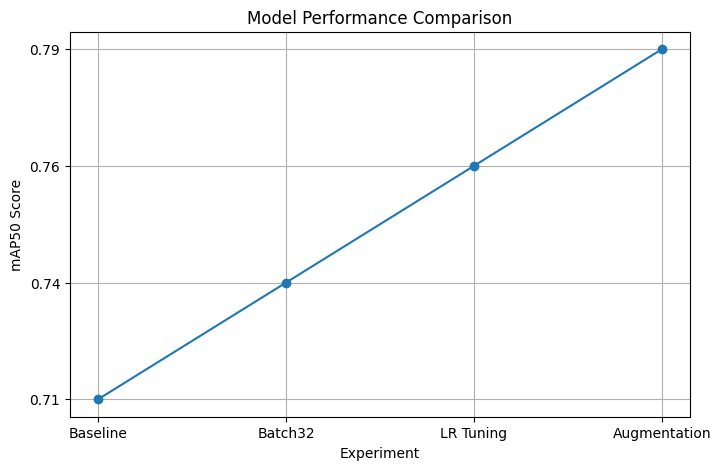

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results["Model"], results["mAP50"], marker='o')
plt.title("Model Performance Comparison")
plt.xlabel("Experiment")
plt.ylabel("mAP50 Score")
plt.grid(True)

plt.show()

In [30]:
from ultralytics import YOLO

final_model = YOLO("runs/detect/exp_augmentation/weights/best.pt")

In [31]:
metrics = final_model.val()

print(metrics)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.1±0.7 ms, read: 241.9±26.4 MB/s, size: 126.6 KB)
val: Scanning /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/val... 1000 images, 394 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1000/1000 1.2Kit/s 0.8s0ss
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 63/63 8.8it/s 7.1s<0.2s
                   all       1000       4888      0.365       0.23      0.211      0.102
    Aortic enlargement        417        970      0.567      0.633      0.652      0.369
           Atelectasis         27         42      0.177     0.0952     0.0844     0.0279
         Calcification         64        14

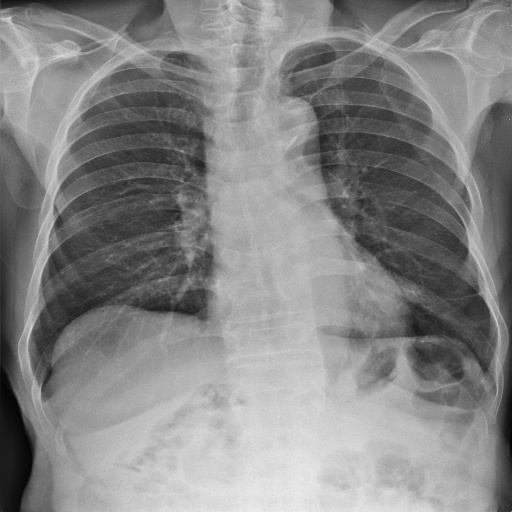

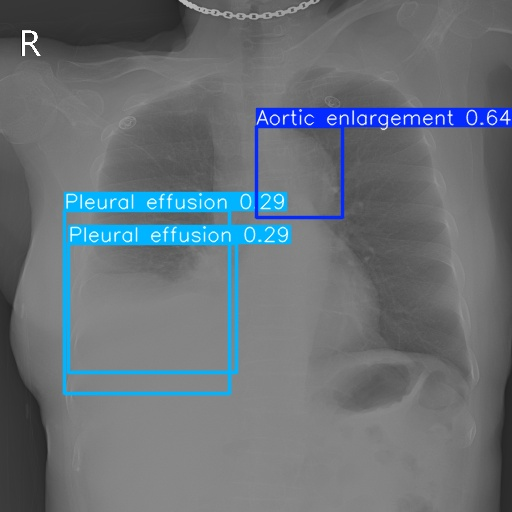

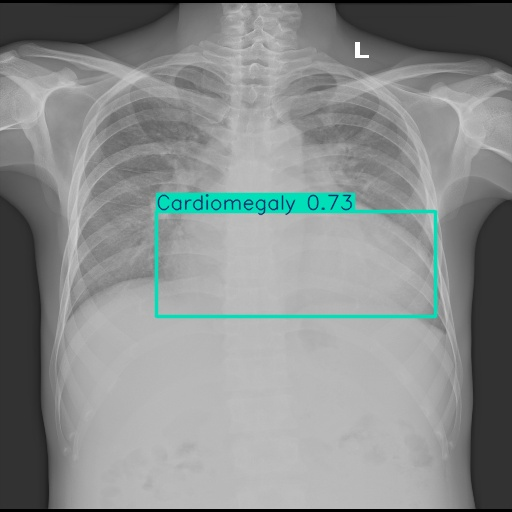

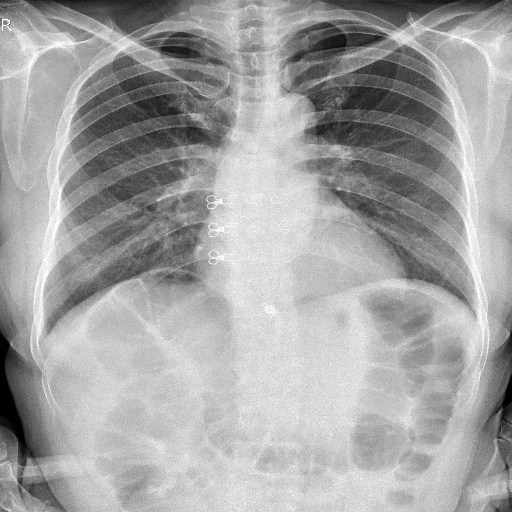

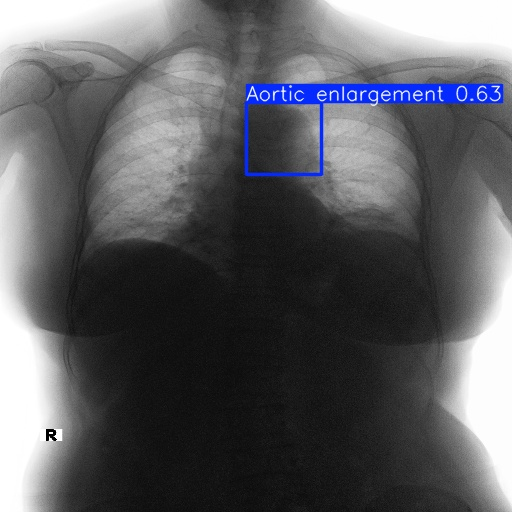

In [35]:
from IPython.display import Image, display
import os

path = "/kaggle/working/runs/detect/predict"

for img in os.listdir(path)[:5]:
    display(Image(filename=f"{path}/{img}"))